# Week 2 Report

**Date:** 2026-06-01 to 2026-06-07

## Goals for this week

- [ ] Get set up with Jupyter notebooks and pandas, numpy, and matplotlib in python 
- [ ] Continue Familiarization with Data
- [ ] Extend Dataset

## What I did

The main task I focused on this week was defining three functions using pandas, numpy, matplotlib, and scikit.learn. 

The first of these functions conducts a multiple linear regression on an inputted dataset for an inputted observation, and returns
the Mean Absolute Error, Mean Squared Error, Root Mean Squared Error, R Squared Value, Adjusted R Squared Value, Coefficients for
each input variable, standard deviations for each input variable, and the standard deviation of the observation (for reference while
interpreting results).

The second of these functions creates a scatter plot of one column versus another and creates a best fit line for the data plotted. Most of my focus in doing this was to become more comfortable with matplotlib and seaborn, as well as generate a few useful graphics for the upcoming presentation at this Tuesday's Project Information Report Seminar

The final function is a function that performs a Principal Component Analysis on an inputted X and y dataset, graphing the first two and three principal components. I still struggle to interpret the results of PCAs, but am confident I would be able to reproduce this code for any smaller dataset should the need arise.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy as sp
import seaborn as sns
from scipy.optimize import curve_fit
from sklearn import linear_model
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression

pa_gs = pd.read_csv('/home/reu/project/data/pa_data.csv').dropna()

#divide data into three broad categories based on distance from body of water
coastal_pa_stations = pa_gs[pa_gs['dist_atlantic_km']< 150]
lakeside_pa_stations = pa_gs[pa_gs['dist_greatlakes_km']< 150]
inland_pa_stations = pa_gs[pa_gs['dist_coast_km']>150]

def scatter_best_fit(data_subset, data_subset_name, xaxis, yaxis, xlabelfull, xlabelabv, ylabelfull, ylabelabv, deg_fit):
    #creates a scatter plot with a best fit line of choice, from a data set or subset, taking in column choices for the x axis
    # and the y axis, preferred labels for each axis and the data set, and the desired degree of the line of best fit.

    #required libraries: seaborn as sns, matplotlib.pyplot as plt

    #creates title text for degree fit for grammatical accuracy
    if deg_fit == 1:
        fit = 'linear'
    elif deg_fit == 2:
        fit = 'quadratic'
    elif deg_fit == 3:
        fit = 'cubic'
    else:
        fit = f'{deg_fit}th degree'

    #creates scatterplot, best fit line, labels, title, and graphs
    sns.scatterplot(x=data_subset[xaxis], y=data_subset[yaxis])
    sns.regplot(x=data_subset[xaxis], y=data_subset[yaxis], ci=None, order=deg_fit, line_kws={"color":"red"})
    plt.xlabel(xlabelabv)
    plt.ylabel(ylabelabv, fontsize =10)
    plt.title(f'{xlabelfull} vs. {ylabelfull} with {fit} best fit line')
    
    return plt.show()



def multiple_regression(input_variables, predicted_variable):
    #performs a standardized multiple linear regression to create a model of y based on the variables within X.
    # Required Libraries: r2score, mean_absolute_error, and mean_squared_error from sklearn.metrics, 
    # train_test_split from sklearn.model_selection, linear_model from sklearn, and StandardScaler from sklearn.preprocessing
    
    #drops NaN values from selected variables
    #input_variables_no_na = input_variables.dropna()
    tot_data_points = int(len(input_variables))
    ## I would prefer that the data cleaning happens within the function both so it's not a prerequisite to run the function
    ## and so the maximum amount of data can be considered for a given regression, but right now the code above makes the
    ## function error out.
    
    #splits data into training and testing groups
    X_train, X_test, y_train, y_test = train_test_split(input_variables, predicted_variable, test_size = 0.2, random_state =0)

    #scales input data to standardize to mean of 0 and standard deviation of 1
    sc = StandardScaler()
    X_train_scaled = sc.fit_transform(X_train)
    X_test_scaled = sc.fit_transform(X_test)
    
    #creates multiple regression model based on training data
    regr = linear_model.LinearRegression()
    regr.fit(X_train_scaled, y_train)

    #calculates mean absolute error, mean squared error, and r squared score based on the predicted y
    y_predicted = regr.predict(X_test_scaled)
    mae = mean_absolute_error(y_test, y_predicted)
    mse = mean_squared_error(y_test, y_predicted)
    rmse = np.sqrt(mse)
    r_2_score = r2_score(y_test, y_predicted)
    n = len(predicted_variable)
    p = input_variables.shape[1]
    adj_r2_score = 1 - ((1 - r_2_score) * (n - 1) / (n - p - 1))
    y_std = predicted_variable.std()
    coefficients = pd.DataFrame(zip(input_variables.columns, input_variables.std(), regr.coef_))

    coefficients.columns = ['variable', 'var standard dev', 'coefficient']
    
    results = [f'MAE = {mae}', f'MSE = {mse}', f'RMSE = {rmse}', f'R Squared = {r_2_score}', 
               f'Adj. R Squared = {adj_r2_score}', f'Total Data Points: {tot_data_points}', 
               f'(Reference) predicted variable standard deviation = {y_std}', coefficients]
    
    return display(results)

def principal_component_analysis(X, y):
    #creates and graphs principal component analysis for inputted X and y
    #required libraries: from sklearn.preprocessing import StandardScalar, from sklearn.decomposition import PCA,
    #from sklearn.linear_model import LinearRegression, matplotlib.pyplot as plt, numpy as np, and pandas as pd.

    #gets list of columns in input X for future conversion of X_train back into dataframe
    columns_X = list(X.columns)

    # splits data into X_train, X_test, y_train, and y_test and makes X_train a dataframe
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 0)
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_train = pd.DataFrame(X_train, columns = columns_X)

    # First PCA
    pca1 = PCA()
    X_pca1 = pca1.fit_transform(X_train)
    plt.bar(range(1,len(pca1.explained_variance_)+1),pca1.explained_variance_)
    plt.ylabel('Explained Variance')
    plt.xlabel('Components')
    plt.plot(range(1,len(pca1.explained_variance_)+1), np.cumsum(pca1.explained_variance_), 
         c='red', label = 'Cumulative Explained Variance')
    plt.legend(loc='upper left')
    plt.show()

    # Second PCA
    pca2b = PCA(n_components=2)
    X_pca2b = pca2b.fit_transform(X_train)
    colormap = plt.get_cmap('coolwarm')
    plt.figure()
    scatter = plt.scatter(X_pca2b[:, 0], X_pca2b[:, 1], c=y_train, cmap= colormap)
    plt.xlabel('PC1')
    plt.ylabel('PC2')
    plt.colorbar(scatter, label = 'Growing Season Length')
    plt.show()

    # Third PCA
    pca3 = PCA(n_components=3)
    X_pca3 = pca3.fit_transform(X_train)

    fig = plt.figure()
    ax = fig.add_subplot(111, projection='3d')
    ax.scatter(X_pca3[:, 0], X_pca3[:, 1], X_pca3[:, 2], c=y_train, cmap=colormap)
    ax.set_xlabel('PC1')
    ax.set_ylabel('PC2')
    ax.set_zlabel('PC3')
    plt.show()

## Analysis

*(Add code and markdown cells as needed.)*

## Results and figures

First run of a multiple linear regression found bewteen 79 and 81 % of variance in growing season length explainable from inputting all other columns of data into the model

In [4]:
y = pa_gs['growing_season_length']
X = pa_gs[['dtr_annual', 'dtr_spring', 'dtr_summer', 'tmax_annual', 'prcp_annual_mm', 'prcp_growing_season_mm', 
    'prcp_spring_mm', 'latitude', 'longitude', 'elevation_m', 'dist_coast_km', 'dist_greatlakes_km', 'dist_atlantic_km',
    'oni_annual', 'nao_annual', 'nao_djf', 'pna_annual', 'amo_annual', 'ohc700_atlantic', 'ohc700_atlantic_se', 
    'ohc700_north_atlantic', 'ohc700_north_atlantic_se', 'ohc700_south_atlantic', 'ohc700_south_atlantic_se', 
    'ohc2000_north_atlantic', 'ohc700_pacific', 'ohc700_world','ohc700_natl_djf', 'ohc700_natl_amj', 'sst_north_atlantic',
    'sst_gulf_stream', 'sst_gulf_mexico', 'sst_tropical_north_atl', 'pwat_eastern_us', 'pwat_southeast_us', 
    'pwat_northeast_us', 'pwat_gulf_coast', 'pwat_station', 'dewpoint_2m_eastern_us', 'soil_moisture_eastern_us',
    'cloud_cover_eastern_us', 'evaporation_eastern_us', 'dewpoint_2m_southeast_us', 'soil_moisture_southeast_us',
    'cloud_cover_southeast_us', 'evaporation_southeast_us', 'dewpoint_2m_northeast_us', 'soil_moisture_northeast_us',
    'cloud_cover_northeast_us', 'evaporation_northeast_us', 'dewpoint_2m_pennsylvania', 'soil_moisture_pennsylvania',
    'cloud_cover_pennsylvania', 'evaporation_pennsylvania', 'dewpoint_station', 'soil_moisture_station',
    'cloud_cover_station', 'evaporation_station']]
multiple_regression(X, y)

['MAE = 8.653954401679119',
 'MSE = 118.54336216146942',
 'RMSE = 10.887762036409017',
 'R Squared = 0.802483321255483',
 'Adj. R Squared = 0.7956683495914842',
 'Total Data Points: 1740',
 '(Reference) predicted variable standard deviation = 25.128478100584672',
                       variable  var standard dev  coefficient
 0                   dtr_annual          1.162618    -9.448399
 1                   dtr_spring          1.463406    -0.783348
 2                   dtr_summer          1.351448     1.657061
 3                  tmax_annual          1.650279     8.417943
 4               prcp_annual_mm        224.681732   -16.306781
 5       prcp_growing_season_mm        184.123407    20.479302
 6               prcp_spring_mm         85.879985     3.166995
 7                     latitude          0.672409   -11.853968
 8                    longitude          1.749712     7.593680
 9                  elevation_m        158.326516    -1.458976
 10               dist_coast_km         60.

While my initial attempts to refine this model did not cause signficant decreases to its accuracy while removing inputs with smaller coefficients or inputs that were not logically relevant to PA's growing season, I was unable to increase the R2 or Adjusted R2, or decrease the MAE, MSE, or RMSE.

In terms of my graphing function, here are three examples of graphs produced by the function:

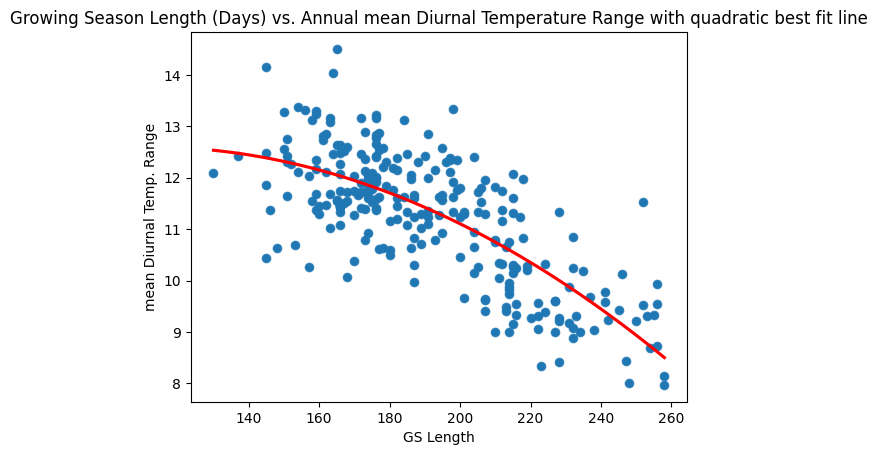

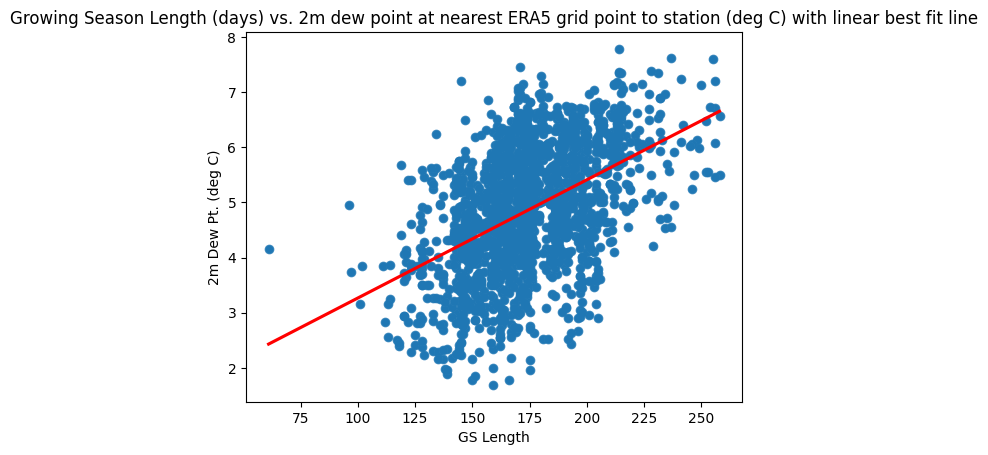

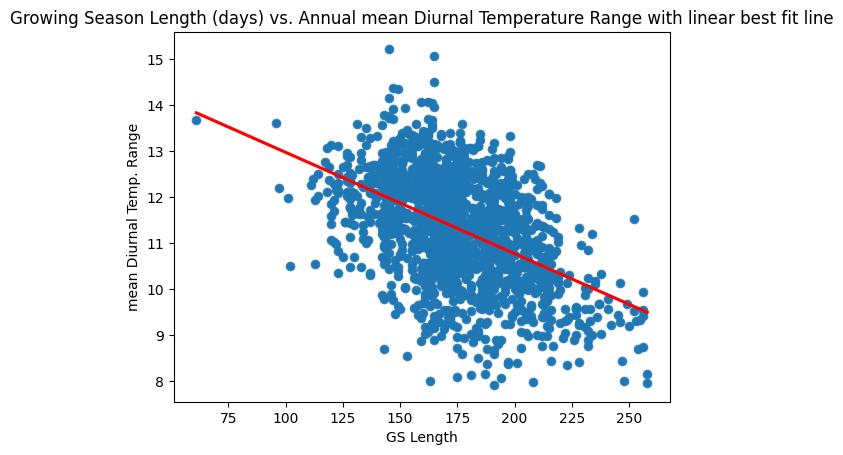

In [4]:
scatter_best_fit(coastal_pa_stations,'coastal', 'growing_season_length', 'dtr_annual', 'Growing Season Length (Days)', 'GS Length', 
                 'Annual mean Diurnal Temperature Range', 'mean Diurnal Temp. Range', 2) 
scatter_best_fit(pa_gs, 'PA', 'growing_season_length', 'dewpoint_station', 'Growing Season Length (days)',
'GS Length', '2m dew point at nearest ERA5 grid point to station (deg C)', '2m Dew Pt. (deg C)', 1)
scatter_best_fit(pa_gs, 'PA', 'growing_season_length', 'dtr_annual', 'Growing Season Length (days)',
'GS Length', 'Annual mean Diurnal Temperature Range', 'mean Diurnal Temp. Range', 1)

Finally, here is the current output of my Principal Component Analysis function. This is certainly the function I created this week that I am the least confident in, both for its accuracy as well as its interpretation, so feedback is very much welcome to improve the function itself as well as the output and interpretation aides.

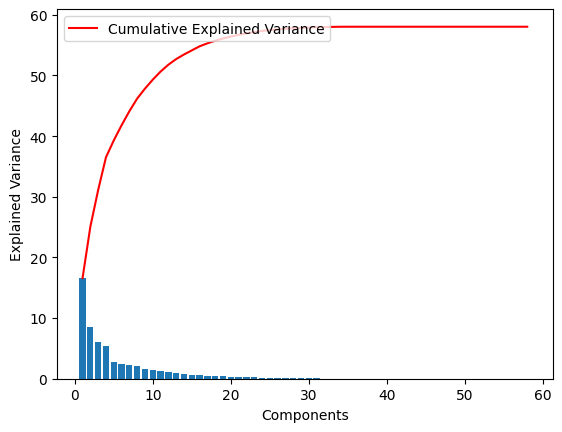

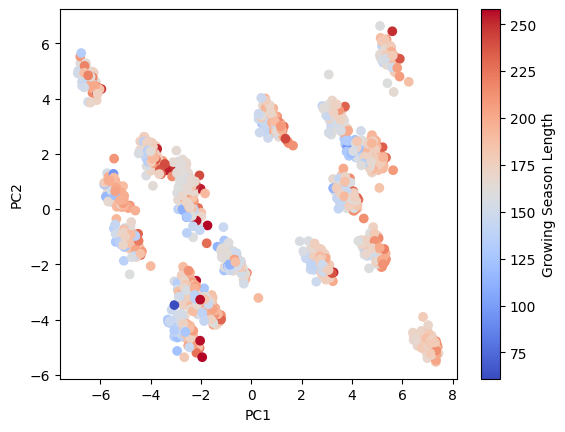

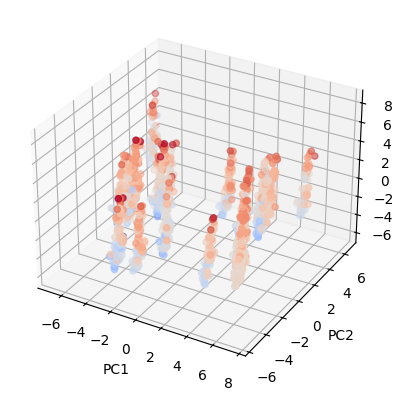

In [5]:
principal_component_analysis(X,y)

## Questions and blockers

- I'm struggling to find and implement productive means of refining the linear regression model. I've looked into the ways that immediately come up such as elimiating collinearity, but have not been successful in implementing code that performs these processes to have a more structured refinement of the model
- As mentioned above, I have been unable to resolve the issue when plotting lines of best fit of degree >1. I'm relatively confident the issue is found in the plotting of the calculated best fit line, but am not entirely certain of that either.
- PCA --> I was successfully able to create a PCA analysis on the whole dataset and graph it a few different ways, and understand how to find the percentage of variance accounted for by each PC, but am confused about what I should interpret each PC as (how does one translate the contents of the PC back to english? should that be my goal or should I be OK with just taking the principal components to be simply unknown combinations of the inputted data?)

## Plan for next week

- [ ] Begin defining & refining guiding question
- [ ] Continue working to better understand PCA, its interpretations, its uses, and methods for coding it into models
- [ ] Take into consideration any other suggestions and refinements to this past week's work, as well as other directions for the upcoming week I have not anticipated in this broadly defined plan